# Cooperative Game Theory for Fair and Stable Savings Sharing in a Microgrid

This notebook converts the provided project proposal into an executable, traceable analysis.

Core workflow:
- Build a microgrid scenario with N households (hourly load, PV generation, optional batteries, electricity prices).
- Solve optimization problems:
  - Solo (each household acts independently).
  - Coalition pooling (a coalition shares energy internally; the grid sees only the net import/export).
- Define a cooperative (TU) game with coalition value v(S) = savings from cooperation.
- Compute and compare savings allocation rules:
  - Shapley value (fairness by marginal contribution),
  - Core stability tests (blocking coalitions),
  - Heuristic allocations (equal split, PV-proportional, contribution-proportional),
  - Least-core (optional advanced: ε-core minimal ε).
- Report required metrics and produce visualizations:
  savings, peak import reduction, PV self-consumption, fairness proxies, stability diagnostics,
  plus scenario and sensitivity comparisons.


## Notation and units

Time step: 1 hour (so kW limits are numerically kWh per hour).
- L_i(t): household i load [kWh]
- G_i(t): household i PV generation [kWh]
- SOC_i(t): battery state of charge [kWh]
- c_buy(t): grid import price [EUR/kWh]
- c_sell(t): grid export price [EUR/kWh]

Solo cost (household i): minimize Σ_t (c_buy(t)*Import_i(t) - c_sell(t)*Export_i(t))
Coalition cost (coalition S): same objective but with pooling so the grid sees net Import_S(t)/Export_S(t)

Coalition value (savings):
  v(S) = Σ_{i∈S} C_solo(i) - C_coal(S)

In [67]:
from __future__ import annotations

import itertools
import logging
import math
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, FrozenSet, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import linprog

# Optional plotting libraries (nice-to-have, not required)
try:
    import seaborn as sns  # type: ignore
except Exception:  # pragma: no cover
    sns = None  # type: ignore

try:
    import plotly.express as px  # type: ignore
except Exception:  # pragma: no cover
    px = None  # type: ignore

np.set_printoptions(suppress=True, precision=6)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)
logger = logging.getLogger("microgrid-coop-game")


In [68]:
PROJECT_ROOT = Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"

# Create folders if they do not exist (safe in notebooks)
for _dir in [DATA_DIR, OUTPUT_DIR, FIG_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

DEFAULT_RANDOM_SEED = 42

In [69]:
@dataclass(frozen=True)
class BatterySpec:
    """Battery specifications for a single household.

    Units assume a 1-hour time step:
      - kW limit is numerically equal to kWh per hour (kWh/step).
    """
    capacity_kwh: float
    max_charge_kw: float
    max_discharge_kw: float
    eta_charge: float = 0.95
    eta_discharge: float = 0.95

    def validate(self) -> None:
        if self.capacity_kwh < 0:
            raise ValueError("Battery capacity_kwh must be >= 0.")
        if self.max_charge_kw < 0 or self.max_discharge_kw < 0:
            raise ValueError("Battery power limits must be >= 0.")
        if not (0 < self.eta_charge <= 1) or not (0 < self.eta_discharge <= 1):
            raise ValueError("Battery efficiencies must be in (0, 1].")

    @property
    def enabled(self) -> bool:
        return self.capacity_kwh > 0 and (self.max_charge_kw > 0 or self.max_discharge_kw > 0)


@dataclass(frozen=True)
class ScenarioData:
    """Container for all inputs needed to solve a scenario."""
    name: str
    households: List[str]  # e.g., ["H1", "H2", ...]
    load_kwh: pd.DataFrame  # index: hour (int), columns: households
    pv_kwh: pd.DataFrame    # index: hour (int), columns: households
    price_buy_eur_per_kwh: pd.Series   # index aligned to hours
    price_sell_eur_per_kwh: pd.Series  # index aligned to hours
    batteries: Dict[str, BatterySpec]
    initial_soc_kwh: Dict[str, float]

    def validate(self) -> None:
        if self.load_kwh.shape != self.pv_kwh.shape:
            raise ValueError("load_kwh and pv_kwh must have the same shape and columns.")
        if list(self.load_kwh.columns) != self.households:
            raise ValueError("ScenarioData.households must match load_kwh columns order.")
        if list(self.pv_kwh.columns) != self.households:
            raise ValueError("ScenarioData.households must match pv_kwh columns order.")
        if not self.load_kwh.index.equals(self.price_buy_eur_per_kwh.index):
            raise ValueError("price_buy_eur_per_kwh index must match load_kwh index.")
        if not self.load_kwh.index.equals(self.price_sell_eur_per_kwh.index):
            raise ValueError("price_sell_eur_per_kwh index must match load_kwh index.")
        if (self.load_kwh.values < 0).any():
            raise ValueError("load_kwh must be non-negative.")
        if (self.pv_kwh.values < 0).any():
            raise ValueError("pv_kwh must be non-negative.")
        for h in self.households:
            if h not in self.batteries:
                raise ValueError(f"Missing battery spec for household {h}.")
            self.batteries[h].validate()
            if h not in self.initial_soc_kwh:
                raise ValueError(f"Missing initial SOC for household {h}.")
            soc0 = self.initial_soc_kwh[h]
            if soc0 < 0 or soc0 > self.batteries[h].capacity_kwh + 1e-9:
                raise ValueError(f"Initial SOC for {h} must be within [0, capacity].")


@dataclass
class LPOutcome:
    """Standardized LP outcome returned by solvers."""
    objective_cost_eur: float
    import_kwh: np.ndarray
    export_kwh: np.ndarray
    charge_kwh: Optional[Dict[str, np.ndarray]]  # per household (coalition) or None (solo)
    discharge_kwh: Optional[Dict[str, np.ndarray]]
    soc_kwh: Optional[Dict[str, np.ndarray]]
    raw_solution: np.ndarray

In [70]:
def _gaussian(x: np.ndarray, mu: float, sigma: float) -> np.ndarray:
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def generate_synthetic_profiles(
    households: List[str],
    hours: np.ndarray,
    *,
    random_seed: int,
    pv_households: Iterable[str],
    battery_households: Iterable[str],
    load_scale_range: Tuple[float, float] = (0.8, 1.4),
    pv_peak_kw_range: Tuple[float, float] = (2.0, 4.0),
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, BatterySpec], Dict[str, float]]:
    """Generate synthetic hourly load and PV profiles consistent with the proposal.

    The proposal suggests a daily load curve with morning/evening peaks and a PV curve
    peaking around midday. This generator builds exactly that family of shapes and
    introduces cross-household heterogeneity by scaling and noise.

    Returns
    -------
    load_kwh, pv_kwh : DataFrames with shape (T, n_households)
    batteries        : dict household -> BatterySpec
    initial_soc_kwh  : dict household -> float
    """
    rng = np.random.default_rng(random_seed)
    T = len(hours)

    pv_households = set(pv_households)
    battery_households = set(battery_households)

    # Base shapes
    morning_peak = _gaussian(hours, mu=8.0, sigma=1.6)
    evening_peak = _gaussian(hours, mu=19.0, sigma=2.0)
    base_load_shape = 0.35 + 0.35 * morning_peak + 0.55 * evening_peak

    base_pv_shape = _gaussian(hours, mu=12.0, sigma=2.6)
    base_pv_shape = base_pv_shape / max(base_pv_shape.max(), 1e-12)

    load = np.zeros((T, len(households)), dtype=float)
    pv = np.zeros((T, len(households)), dtype=float)

    batteries: Dict[str, BatterySpec] = {}
    initial_soc: Dict[str, float] = {}

    for j, h in enumerate(households):
        load_scale = rng.uniform(*load_scale_range)
        noise = rng.normal(loc=0.0, scale=0.04, size=T)
        profile = (load_scale * base_load_shape + noise).clip(min=0.05)

        # Convert to kWh per hour profile with realistic daily energy (8–18 kWh/day)
        daily_kwh_target = rng.uniform(8.0, 18.0)
        profile = profile / profile.sum() * daily_kwh_target
        load[:, j] = profile

        if h in pv_households:
            pv_peak_kw = rng.uniform(*pv_peak_kw_range)
            pv_noise = rng.normal(loc=0.0, scale=0.03, size=T)
            pv_profile = (pv_peak_kw * base_pv_shape + pv_noise).clip(min=0.0)
            pv[:, j] = pv_profile  # kWh per hour (1h step)
        else:
            pv[:, j] = 0.0

        if h in battery_households:
            # Simple heterogeneous battery specs (can be overridden later)
            cap = float(rng.choice([4.0, 6.0, 8.0]))
            pmax = float(rng.choice([1.5, 2.0, 2.5]))
            batt = BatterySpec(capacity_kwh=cap, max_charge_kw=pmax, max_discharge_kw=pmax)
        else:
            batt = BatterySpec(capacity_kwh=0.0, max_charge_kw=0.0, max_discharge_kw=0.0)

        batteries[h] = batt
        initial_soc[h] = 0.5 * batt.capacity_kwh  # common and easy default

    load_kwh = pd.DataFrame(load, index=pd.Index(hours, name="hour"), columns=households)
    pv_kwh = pd.DataFrame(pv, index=pd.Index(hours, name="hour"), columns=households)
    return load_kwh, pv_kwh, batteries, initial_soc


def build_time_of_use_prices(
    hours: np.ndarray,
    *,
    base_buy: float = 0.12,
    peak_buy: float = 0.22,
    shoulder_buy: float = 0.18,
    sell: float = 0.06,
) -> Tuple[pd.Series, pd.Series]:
    """Simple time-of-use (TOU) buy price and a constant sell price."""
    buy = np.full_like(hours, fill_value=base_buy, dtype=float)
    buy[(hours >= 18) & (hours <= 22)] = peak_buy
    buy[(hours >= 7) & (hours <= 9)] = shoulder_buy
    sell_arr = np.full_like(hours, fill_value=sell, dtype=float)

    buy_s = pd.Series(buy, index=pd.Index(hours, name="hour"), name="price_buy_eur_per_kwh")
    sell_s = pd.Series(sell_arr, index=pd.Index(hours, name="hour"), name="price_sell_eur_per_kwh")
    return buy_s, sell_s


def scenario_from_proposal(name: str) -> ScenarioData:
    """Create one of the scenarios explicitly described in the proposal."""
    if name.lower() in {"scenario_1", "scenario1", "s1"}:
        n = 5
        households = [f"H{i}" for i in range(1, n + 1)]
        hours = np.arange(24)
        price_buy, price_sell = build_time_of_use_prices(hours, base_buy=0.12, peak_buy=0.18, shoulder_buy=0.15, sell=0.06)

        pv_households = {"H1", "H3"}          # proposal: 2 households with PV
        battery_households = {"H2"}           # proposal: 1 household with battery
        load_kwh, pv_kwh, batteries, soc0 = generate_synthetic_profiles(
            households, hours,
            random_seed=1,
            pv_households=pv_households,
            battery_households=battery_households,
        )

    elif name.lower() in {"scenario_2", "scenario2", "s2"}:
        n = 8
        households = [f"H{i}" for i in range(1, n + 1)]
        hours = np.arange(24)
        price_buy, price_sell = build_time_of_use_prices(hours, base_buy=0.12, peak_buy=0.22, shoulder_buy=0.18, sell=0.06)

        pv_households = {"H1", "H3", "H5", "H7"}     # proposal: 4 households with PV
        battery_households = {"H2", "H4", "H6"}      # proposal: 3 households with batteries
        load_kwh, pv_kwh, batteries, soc0 = generate_synthetic_profiles(
            households, hours,
            random_seed=2,
            pv_households=pv_households,
            battery_households=battery_households,
        )

    elif name.lower() in {"scenario_3", "scenario3", "s3"}:
        n = 8
        households = [f"H{i}" for i in range(1, n + 1)]
        hours = np.arange(24)

        # Stress test: low sell price makes exports unattractive.
        price_buy, price_sell = build_time_of_use_prices(hours, base_buy=0.12, peak_buy=0.25, shoulder_buy=0.20, sell=0.02)

        pv_households = {"H1", "H2", "H3", "H4", "H5", "H6"}  # high PV penetration
        battery_households = {"H2", "H4", "H6"}               # some batteries
        load_kwh, pv_kwh, batteries, soc0 = generate_synthetic_profiles(
            households, hours,
            random_seed=3,
            pv_households=pv_households,
            battery_households=battery_households,
            pv_peak_kw_range=(3.0, 6.0),  # higher PV peak
        )

    else:
        raise ValueError("Unknown scenario name. Use scenario_1 / scenario_2 / scenario_3.")

    scenario = ScenarioData(
        name=name,
        households=households,
        load_kwh=load_kwh,
        pv_kwh=pv_kwh,
        price_buy_eur_per_kwh=price_buy,
        price_sell_eur_per_kwh=price_sell,
        batteries=batteries,
        initial_soc_kwh=soc0,
    )
    scenario.validate()
    return scenario


def load_profiles_from_csv(
    csv_path: Path,
    *,
    household_prefix: str = "H",
) -> ScenarioData:
    """Load hourly load/PV and price data from a CSV (user-provided).

    Expected columns:
      - hour (int)
      - price_buy_eur_per_kwh
      - price_sell_eur_per_kwh
      - load_<household_id> and pv_<household_id> (e.g., load_H1, pv_H1, ...)

    Battery specs are left as 'no battery' by default and should be filled by the user.
    See docs/DATA_SCHEMA.md provided in this deliverable.
    """
    df = pd.read_csv(csv_path)
    if "hour" not in df.columns:
        raise ValueError("CSV must include a 'hour' column.")

    df = df.set_index("hour").sort_index()

    required_price_cols = {"price_buy_eur_per_kwh", "price_sell_eur_per_kwh"}
    missing = required_price_cols - set(df.columns)
    if missing:
        raise ValueError(f"CSV is missing required price columns: {sorted(missing)}")

    load_cols = [c for c in df.columns if c.startswith("load_")]
    pv_cols = [c for c in df.columns if c.startswith("pv_")]

    if not load_cols:
        raise ValueError("CSV must include at least one load_* column.")

    households = sorted({c.replace("load_", "") for c in load_cols})
    # Basic sanity checks for matching PV columns.
    for h in households:
        if f"load_{h}" not in df.columns:
            raise ValueError(f"Missing load column for household {h}.")
        if f"pv_{h}" not in df.columns:
            df[f"pv_{h}"] = 0.0

    load_kwh = df[[f"load_{h}" for h in households]].rename(columns={f"load_{h}": h for h in households})
    pv_kwh = df[[f"pv_{h}" for h in households]].rename(columns={f"pv_{h}": h for h in households})

    batteries = {h: BatterySpec(0.0, 0.0, 0.0) for h in households}
    initial_soc = {h: 0.0 for h in households}

    scenario = ScenarioData(
        name=f"csv:{csv_path.name}",
        households=households,
        load_kwh=load_kwh.astype(float),
        pv_kwh=pv_kwh.astype(float),
        price_buy_eur_per_kwh=df["price_buy_eur_per_kwh"].astype(float),
        price_sell_eur_per_kwh=df["price_sell_eur_per_kwh"].astype(float),
        batteries=batteries,
        initial_soc_kwh=initial_soc,
    )
    scenario.validate()
    return scenario


In [71]:
def plot_input_profiles(scenario: ScenarioData) -> None:
    """Plot household load and PV profiles, plus the buy/sell tariff."""
    hours = scenario.load_kwh.index.values

    # Load profiles
    plt.figure(figsize=(10, 4))
    for h in scenario.households:
        plt.plot(hours, scenario.load_kwh[h].values, label=f"{h} load")
    plt.title(f"Household load profiles | {scenario.name}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # PV profiles
    plt.figure(figsize=(10, 4))
    for h in scenario.households:
        if scenario.pv_kwh[h].values.max() > 1e-9:
            plt.plot(hours, scenario.pv_kwh[h].values, label=f"{h} PV")
    plt.title(f"Household PV generation profiles | {scenario.name}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # Prices
    plt.figure(figsize=(10, 3))
    plt.plot(hours, scenario.price_buy_eur_per_kwh.values, label="Buy price")
    plt.plot(hours, scenario.price_sell_eur_per_kwh.values, label="Sell price")
    plt.title(f"Electricity prices | {scenario.name}")
    plt.xlabel("Hour")
    plt.ylabel("EUR/kWh")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example selection (do not run automatically if you want a clean notebook)
# scenario = scenario_from_proposal("scenario_1")
# plot_input_profiles(scenario)


## Optimization models (LP)

Solo household i:
- Variables each hour: Import_i(t), Export_i(t), Charge_i(t), Discharge_i(t)
- SOC dynamics across hours enforces battery feasibility.
- Objective: minimize energy cost (buy price * imports - sell price * exports)

Coalition pooling (coalition S):
- Grid interaction is aggregated: Import_S(t), Export_S(t)
- Household batteries remain per-household, but the coalition energy balance is shared.
- This is the standard "lossless internal pooling" approximation.

The LP is solved using SciPy's linprog (HiGHS).


In [72]:
def _solve_linprog(
    c: np.ndarray,
    *,
    A_eq: Optional[np.ndarray],
    b_eq: Optional[np.ndarray],
    A_ub: Optional[np.ndarray],
    b_ub: Optional[np.ndarray],
    bounds: Sequence[Tuple[Optional[float], Optional[float]]],
    method: str = "highs",
) -> np.ndarray:
    """Solve a linear program via SciPy and return the primal solution vector."""
    result = linprog(
        c,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method=method,
    )
    if not result.success:
        raise RuntimeError(f"LP failed: {result.message}")
    if result.x is None:
        raise RuntimeError("LP returned no solution vector.")
    return result.x


def solve_solo_household_lp(
    *,
    household: str,
    load_kwh: np.ndarray,
    pv_kwh: np.ndarray,
    price_buy: np.ndarray,
    price_sell: np.ndarray,
    battery: BatterySpec,
    initial_soc_kwh: float,
    enforce_terminal_soc: bool = True,
    terminal_soc_kwh: Optional[float] = None,
    method: str = "highs",
) -> LPOutcome:
    """Solve the 'solo' LP for a single household.

    Decision variables per hour t (T = len(load_kwh)):
      - import_t, export_t, charge_t, discharge_t
    Plus SOC for t=0..T.

    Energy balance:
      import + pv + discharge = load + charge + export

    SOC dynamics:
      soc[t+1] = soc[t] + eta_charge * charge[t] - discharge[t] / eta_discharge
    """
    T = len(load_kwh)
    if not (len(pv_kwh) == len(price_buy) == len(price_sell) == T):
        raise ValueError("All time series must have the same length.")

    battery.validate()
    if terminal_soc_kwh is None and enforce_terminal_soc:
        terminal_soc_kwh = initial_soc_kwh

    # Variable layout:
    # [0:T)           import
    # [T:2T)          export
    # [2T:3T)         charge
    # [3T:4T)         discharge
    # [4T:4T+T+1)     soc (length T+1)
    idx_import = slice(0, T)
    idx_export = slice(T, 2 * T)
    idx_charge = slice(2 * T, 3 * T)
    idx_discharge = slice(3 * T, 4 * T)
    idx_soc = slice(4 * T, 4 * T + (T + 1))
    n_var = 4 * T + (T + 1)

    c = np.zeros(n_var, dtype=float)
    c[idx_import] = price_buy
    c[idx_export] = -price_sell  # revenue reduces cost

    # Equality constraints
    eq_rows: List[np.ndarray] = []
    eq_rhs: List[float] = []

    # Energy balance for each hour
    for t in range(T):
        row = np.zeros(n_var, dtype=float)
        row[idx_import.start + t] = 1.0
        row[idx_export.start + t] = -1.0
        row[idx_charge.start + t] = -1.0
        row[idx_discharge.start + t] = 1.0
        eq_rows.append(row)
        eq_rhs.append(float(load_kwh[t] - pv_kwh[t]))

    # SOC dynamics for each hour
    for t in range(T):
        row = np.zeros(n_var, dtype=float)
        row[idx_soc.start + (t + 1)] = 1.0
        row[idx_soc.start + t] = -1.0
        row[idx_charge.start + t] = -battery.eta_charge
        row[idx_discharge.start + t] = 1.0 / max(battery.eta_discharge, 1e-12)
        eq_rows.append(row)
        eq_rhs.append(0.0)

    # Initial SOC
    row0 = np.zeros(n_var, dtype=float)
    row0[idx_soc.start + 0] = 1.0
    eq_rows.append(row0)
    eq_rhs.append(float(initial_soc_kwh))

    # Optional terminal SOC
    if enforce_terminal_soc and terminal_soc_kwh is not None:
        rowT = np.zeros(n_var, dtype=float)
        rowT[idx_soc.start + T] = 1.0
        eq_rows.append(rowT)
        eq_rhs.append(float(terminal_soc_kwh))

    A_eq = np.vstack(eq_rows)
    b_eq = np.array(eq_rhs, dtype=float)

    # Bounds
    bounds: List[Tuple[Optional[float], Optional[float]]] = []
    bounds += [(0.0, None)] * T  # import
    bounds += [(0.0, None)] * T  # export

    if battery.enabled:
        bounds += [(0.0, battery.max_charge_kw)] * T
        bounds += [(0.0, battery.max_discharge_kw)] * T
        bounds += [(0.0, battery.capacity_kwh)] * (T + 1)
    else:
        bounds += [(0.0, 0.0)] * T
        bounds += [(0.0, 0.0)] * T
        bounds += [(0.0, 0.0)] * (T + 1)

    x = _solve_linprog(c, A_eq=A_eq, b_eq=b_eq, A_ub=None, b_ub=None, bounds=bounds, method=method)

    imp = x[idx_import]
    exp = x[idx_export]

    cost = float(np.dot(price_buy, imp) - np.dot(price_sell, exp))

    return LPOutcome(
        objective_cost_eur=cost,
        import_kwh=imp,
        export_kwh=exp,
        charge_kwh={household: x[idx_charge]},
        discharge_kwh={household: x[idx_discharge]},
        soc_kwh={household: x[idx_soc]},
        raw_solution=x,
    )


def solve_coalition_pooling_lp(
    *,
    coalition: FrozenSet[str],
    scenario: ScenarioData,
    enforce_terminal_soc: bool = True,
    method: str = "highs",
) -> LPOutcome:
    """Solve the coalition LP assuming lossless, unconstrained internal pooling.

    The grid sees only the coalition's net import/export. Batteries are modeled per
    household, but their discharge can contribute to the coalition-wide power balance
    (i.e., stored energy can be used anywhere in the coalition once discharged).

    This matches the proposal's 'internal pooling' abstraction and is the simplest LP.
    """
    households = [h for h in scenario.households if h in coalition]
    if not households:
        raise ValueError("Coalition must be non-empty.")

    T = len(scenario.load_kwh)

    price_buy = scenario.price_buy_eur_per_kwh.values
    price_sell = scenario.price_sell_eur_per_kwh.values

    # Variable layout:
    # coalition import/export (2T)
    # then for each household: charge (T), discharge (T), soc (T+1)
    idx_import = slice(0, T)
    idx_export = slice(T, 2 * T)

    offsets: Dict[str, Dict[str, slice]] = {}
    cursor = 2 * T
    for h in households:
        idx_charge = slice(cursor, cursor + T)
        cursor += T
        idx_discharge = slice(cursor, cursor + T)
        cursor += T
        idx_soc = slice(cursor, cursor + (T + 1))
        cursor += (T + 1)
        offsets[h] = {"charge": idx_charge, "discharge": idx_discharge, "soc": idx_soc}

    n_var = cursor

    c = np.zeros(n_var, dtype=float)
    c[idx_import] = price_buy
    c[idx_export] = -price_sell

    eq_rows: List[np.ndarray] = []
    eq_rhs: List[float] = []

    load = scenario.load_kwh[households].values
    pv = scenario.pv_kwh[households].values

    # Coalition energy balance per hour:
    # Import - Export - sum(charge) + sum(discharge) = sum(load - pv)
    for t in range(T):
        row = np.zeros(n_var, dtype=float)
        row[idx_import.start + t] = 1.0
        row[idx_export.start + t] = -1.0

        for h in households:
            row[offsets[h]["charge"].start + t] = -1.0
            row[offsets[h]["discharge"].start + t] = 1.0

        eq_rows.append(row)
        eq_rhs.append(float(load[t, :].sum() - pv[t, :].sum()))

    # SOC dynamics, initial SOC, terminal SOC per household
    for h in households:
        batt = scenario.batteries[h]
        batt.validate()
        soc0 = scenario.initial_soc_kwh[h]
        socT = soc0 if enforce_terminal_soc else None

        idx_charge = offsets[h]["charge"]
        idx_discharge = offsets[h]["discharge"]
        idx_soc = offsets[h]["soc"]

        for t in range(T):
            row = np.zeros(n_var, dtype=float)
            row[idx_soc.start + (t + 1)] = 1.0
            row[idx_soc.start + t] = -1.0
            row[idx_charge.start + t] = -batt.eta_charge
            row[idx_discharge.start + t] = 1.0 / max(batt.eta_discharge, 1e-12)
            eq_rows.append(row)
            eq_rhs.append(0.0)

        # initial SOC
        row0 = np.zeros(n_var, dtype=float)
        row0[idx_soc.start + 0] = 1.0
        eq_rows.append(row0)
        eq_rhs.append(float(soc0))

        # optional terminal SOC
        if socT is not None:
            rowT = np.zeros(n_var, dtype=float)
            rowT[idx_soc.start + T] = 1.0
            eq_rows.append(rowT)
            eq_rhs.append(float(socT))

    A_eq = np.vstack(eq_rows)
    b_eq = np.array(eq_rhs, dtype=float)

    bounds: List[Tuple[Optional[float], Optional[float]]] = []
    bounds += [(0.0, None)] * T  # import
    bounds += [(0.0, None)] * T  # export

    for h in households:
        batt = scenario.batteries[h]
        if batt.enabled:
            bounds += [(0.0, batt.max_charge_kw)] * T
            bounds += [(0.0, batt.max_discharge_kw)] * T
            bounds += [(0.0, batt.capacity_kwh)] * (T + 1)
        else:
            bounds += [(0.0, 0.0)] * T
            bounds += [(0.0, 0.0)] * T
            bounds += [(0.0, 0.0)] * (T + 1)

    x = _solve_linprog(c, A_eq=A_eq, b_eq=b_eq, A_ub=None, b_ub=None, bounds=bounds, method=method)

    imp = x[idx_import]
    exp = x[idx_export]
    cost = float(np.dot(price_buy, imp) - np.dot(price_sell, exp))

    charge = {h: x[offsets[h]["charge"]] for h in households}
    discharge = {h: x[offsets[h]["discharge"]] for h in households}
    soc = {h: x[offsets[h]["soc"]] for h in households}

    return LPOutcome(
        objective_cost_eur=cost,
        import_kwh=imp,
        export_kwh=exp,
        charge_kwh=charge,
        discharge_kwh=discharge,
        soc_kwh=soc,
        raw_solution=x,
    )


In [73]:
def iter_coalitions(players: Sequence[str]) -> Iterable[FrozenSet[str]]:
    """Yield all non-empty coalitions as frozensets."""
    players = list(players)
    for r in range(1, len(players) + 1):
        for combo in itertools.combinations(players, r):
            yield frozenset(combo)


def compute_solo_costs(
    scenario: ScenarioData,
    *,
    enforce_terminal_soc: bool = True,
    method: str = "highs",
) -> Tuple[Dict[str, float], Dict[str, LPOutcome]]:
    """Solve solo LPs and return costs and schedules."""
    solo_costs: Dict[str, float] = {}
    solo_outcomes: Dict[str, LPOutcome] = {}

    for h in scenario.households:
        out = solve_solo_household_lp(
            household=h,
            load_kwh=scenario.load_kwh[h].values,
            pv_kwh=scenario.pv_kwh[h].values,
            price_buy=scenario.price_buy_eur_per_kwh.values,
            price_sell=scenario.price_sell_eur_per_kwh.values,
            battery=scenario.batteries[h],
            initial_soc_kwh=scenario.initial_soc_kwh[h],
            enforce_terminal_soc=enforce_terminal_soc,
            method=method,
        )
        solo_costs[h] = out.objective_cost_eur
        solo_outcomes[h] = out

    return solo_costs, solo_outcomes


def compute_characteristic_function(
    scenario: ScenarioData,
    *,
    enforce_terminal_soc: bool = True,
    method: str = "highs",
) -> Tuple[Dict[FrozenSet[str], float], Dict[FrozenSet[str], float], Dict[str, float], Dict[str, LPOutcome]]:
    """Compute v(S) for all coalitions S, along with coalition costs.

    v(S) = sum_{i in S} C_solo(i) - C_coal(S)

    Returns
    -------
    v       : coalition -> savings (EUR)
    c_coal  : coalition -> coalition cost (EUR)
    c_solo  : household -> solo cost (EUR)
    solo_outcomes : household -> full solo schedules (used for metrics)
    """
    scenario.validate()
    players = scenario.households

    solo_costs, solo_outcomes = compute_solo_costs(
        scenario, enforce_terminal_soc=enforce_terminal_soc, method=method
    )

    c_coal: Dict[FrozenSet[str], float] = {}
    v: Dict[FrozenSet[str], float] = {frozenset(): 0.0}

    for S in iter_coalitions(players):
        out = solve_coalition_pooling_lp(
            coalition=S,
            scenario=scenario,
            enforce_terminal_soc=enforce_terminal_soc,
            method=method,
        )
        cS = out.objective_cost_eur
        c_coal[S] = cS
        v[S] = float(sum(solo_costs[h] for h in S) - cS)

    return v, c_coal, solo_costs, solo_outcomes


## Cooperative-game allocations and stability checks

Shapley value:
- A fairness allocation based on expected marginal contributions across all arrival orders.

Core stability:
- Allocation x is stable if no coalition S can do better by deviating:
  sum_{i in S} x_i >= v(S)
Blocking coalitions are coalitions that violate this inequality.

Least-core:
- If the core is empty (or we want a stabilized allocation), minimize epsilon so that:
  sum_{i in S} x_i >= v(S) - epsilon


In [74]:
def shapley_value_exact(players: Sequence[str], v: Dict[FrozenSet[str], float]) -> Dict[str, float]:
    """Compute the exact Shapley value for a TU game.

    Uses the classic subset-weighting formula:
      phi_i = sum_{S subset N\{i}} |S|! (n-|S|-1)! / n! * (v(S ∪ {i}) - v(S))

    Requires v to contain v(empty) = 0.
    """
    players = list(players)
    n = len(players)
    if frozenset() not in v:
        raise ValueError("Characteristic function must include v(empty)=0.")

    n_fact = math.factorial(n)
    phi = {p: 0.0 for p in players}

    player_set = set(players)

    for p in players:
        others = player_set - {p}
        for r in range(0, len(others) + 1):
            for subset in itertools.combinations(sorted(others), r):
                S = frozenset(subset)
                weight = math.factorial(r) * math.factorial(n - r - 1) / n_fact
                marginal = v[S | {p}] - v[S]
                phi[p] += weight * marginal

    return phi


def shapley_value_monte_carlo(
    players: Sequence[str],
    v: Dict[FrozenSet[str], float],
    *,
    n_samples: int = 2000,
    random_seed: int = 0,
) -> Dict[str, float]:
    """Approximate Shapley values by averaging marginal contributions over random permutations."""
    rng = np.random.default_rng(random_seed)
    players = list(players)
    phi = {p: 0.0 for p in players}

    for _ in range(n_samples):
        perm = list(players)
        rng.shuffle(perm)

        S: FrozenSet[str] = frozenset()
        for p in perm:
            newS = S | {p}
            phi[p] += v[newS] - v[S]
            S = newS

    for p in players:
        phi[p] /= n_samples

    return phi


In [75]:
def allocation_equal_split(players: Sequence[str], v_grand: float) -> Dict[str, float]:
    players = list(players)
    if len(players) == 0:
        return {}
    return {p: v_grand / len(players) for p in players}


def allocation_proportional_to_pv(players: Sequence[str], scenario: ScenarioData, v_grand: float) -> Dict[str, float]:
    """Allocate proportionally to total PV energy produced over the horizon."""
    totals = {p: float(scenario.pv_kwh[p].sum()) for p in players}
    total_pv = sum(totals.values())
    if total_pv <= 1e-12:
        return allocation_equal_split(players, v_grand)
    return {p: v_grand * totals[p] / total_pv for p in players}


def compute_net_supply_kwh(
    scenario: ScenarioData,
    coalition_outcome: LPOutcome,
    coalition: FrozenSet[str],
) -> pd.DataFrame:
    """Compute each household's hourly net supply to the coalition pool.

    net_supply[t] = pv[t] + discharge[t] - load[t] - charge[t]
      - Positive means the household contributes energy to the pool.
      - Negative means it consumes pooled energy (net deficit).
    """
    households = [h for h in scenario.households if h in coalition]
    T = len(scenario.load_kwh)
    hours = scenario.load_kwh.index

    if coalition_outcome.charge_kwh is None or coalition_outcome.discharge_kwh is None:
        raise ValueError("Coalition outcome is missing per-household battery schedules.")

    data = {}
    for h in households:
        pv = scenario.pv_kwh[h].values
        load = scenario.load_kwh[h].values
        ch = coalition_outcome.charge_kwh[h]
        dis = coalition_outcome.discharge_kwh[h]
        data[h] = pv + dis - load - ch

    return pd.DataFrame(data, index=hours).iloc[:T]


def allocation_proportional_to_contribution(
    players: Sequence[str],
    scenario: ScenarioData,
    coalition_outcome: LPOutcome,
    coalition: FrozenSet[str],
    v_grand: float,
) -> Dict[str, float]:
    """Allocate proportionally to coalition energy contribution (kWh).

    Contribution proxy: sum_t max(0, net_supply_i[t]).
    This is consistent with the proposal's 'energy a household brought' idea,
    under the pooling abstraction.
    """
    net_supply = compute_net_supply_kwh(scenario, coalition_outcome, coalition)

    contributions = {p: float(np.maximum(net_supply[p].values, 0.0).sum()) for p in players}
    total_contrib = sum(contributions.values())

    if total_contrib <= 1e-12:
        return allocation_equal_split(players, v_grand)

    return {p: v_grand * contributions[p] / total_contrib for p in players}


In [76]:
def core_violations(
    players: Sequence[str],
    v: Dict[FrozenSet[str], float],
    allocation: Dict[str, float],
    *,
    tol: float = 1e-9,
) -> pd.DataFrame:
    """Return coalitions that can block the allocation (core violations).

    A coalition S blocks x if sum_{i in S} x_i < v(S).
    """
    players = list(players)
    records = []

    for S in iter_coalitions(players):
        lhs = sum(allocation.get(p, 0.0) for p in S)
        rhs = v.get(S, 0.0)
        deficit = rhs - lhs

        if deficit > tol:
            records.append({
                "coalition": "+".join(sorted(S)),
                "size": len(S),
                "v_S": rhs,
                "sum_allocation": lhs,
                "deficit": deficit,
            })

    columns = ["coalition", "size", "v_S", "sum_allocation", "deficit"]
    df = pd.DataFrame(records, columns=columns)

    if df.empty:
        return df

    df = df.sort_values(by=["deficit", "size"], ascending=[False, True])
    return df.reset_index(drop=True)


def stability_summary(
    players: Sequence[str],
    v: Dict[FrozenSet[str], float],
    allocation: Dict[str, float],
) -> Dict[str, float]:
    """Compute stability metrics for an allocation."""
    df = core_violations(players, v, allocation)
    worst_deficit = float(df["deficit"].max()) if len(df) else 0.0

    return {
        "blocking_coalitions_count": float(len(df)),
        "worst_deficit": worst_deficit,
        "in_core": float(len(df) == 0),
    }

In [77]:
def allocation_least_core(
    players: Sequence[str],
    v: Dict[FrozenSet[str], float],
    *,
    min_allocation: float = 0.0,
    method: str = "highs",
) -> Tuple[Dict[str, float], float]:
    """Compute a least-core allocation by minimizing epsilon (ε-core LP).

    We solve:
      minimize   ε
      subject to sum_i x_i = v(N)
                 sum_{i in S} x_i >= v(S) - ε  for all non-empty S ⊂ N
                 x_i >= min_allocation

    Returns allocation and optimal epsilon.
    """
    players = list(players)
    N = frozenset(players)
    if N not in v:
        raise ValueError("Characteristic function must include v(N) for the grand coalition.")
    if frozenset() not in v:
        v = {**v, frozenset(): 0.0}

    n = len(players)
    vN = float(v[N])

    # Variables: x_1..x_n, epsilon
    n_var = n + 1
    idx_eps = n

    c = np.zeros(n_var, dtype=float)
    c[idx_eps] = 1.0  # minimize epsilon

    # Equality: sum x_i = v(N)
    A_eq = np.zeros((1, n_var), dtype=float)
    A_eq[0, :n] = 1.0
    b_eq = np.array([vN], dtype=float)

    # Inequalities: sum_{i in S} x_i + epsilon >= v(S)
    # Convert to A_ub x <= b_ub:
    # -(sum_{i in S} x_i + epsilon) <= -v(S)
    A_ub_rows = []
    b_ub_rows = []

    for S in iter_coalitions(players):
        if S == N:
            continue  # grand coalition handled by equality
        row = np.zeros(n_var, dtype=float)
        for i, p in enumerate(players):
            if p in S:
                row[i] = -1.0
        row[idx_eps] = -1.0
        A_ub_rows.append(row)
        b_ub_rows.append(-float(v[S]))

    A_ub = np.vstack(A_ub_rows) if A_ub_rows else None
    b_ub = np.array(b_ub_rows, dtype=float) if b_ub_rows else None

    bounds: List[Tuple[Optional[float], Optional[float]]] = [(min_allocation, None)] * n
    bounds.append((None, None))  # epsilon is free (can be <= 0 if the core is non-empty)

    sol = _solve_linprog(c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method=method)

    alloc = {players[i]: float(sol[i]) for i in range(n)}
    eps = float(sol[idx_eps])
    return alloc, eps


def nucleolus_not_implemented() -> None:
    """Placeholder for an optional advanced extension.

    The proposal lists the nucleolus as an optional advanced variant.
    Computing it robustly typically requires sequential linear programs.
    """
    raise NotImplementedError("Nucleolus computation is not implemented in this notebook template.")


## Metrics, scenario runs, and sensitivity analysis

System-level (proposal-required) metrics:
- Total savings v(N) [EUR]
- Peak import reduction (absolute and %) [kWh/h, %]
- PV self-consumption (solo vs coalition) [%]

Stability metrics:
- Number of blocking coalitions
- Worst deficit
- In-core yes/no

Fairness proxies:
- Correlation of allocation with PV total production
- Gini coefficient of allocations (optional inequality metric)

We run proposal scenarios (Scenario 1/2/3) and then do a sensitivity sweep.


In [78]:
def gini_coefficient(values: Sequence[float]) -> float:
    """Compute the Gini coefficient for non-negative values."""
    x = np.array(values, dtype=float)
    if (x < 0).any():
        raise ValueError("Gini coefficient expects non-negative inputs.")
    if x.size == 0:
        return float("nan")
    if np.allclose(x, 0):
        return 0.0

    x_sorted = np.sort(x)
    n = x_sorted.size
    cumx = np.cumsum(x_sorted)
    gini = (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n
    return float(gini)


def compute_system_metrics(
    scenario: ScenarioData,
    solo_outcomes: Dict[str, LPOutcome],
    grand_outcome: LPOutcome,
) -> Dict[str, float]:
    """Compute system-level metrics requested in the proposal."""
    hours = scenario.load_kwh.index.values
    T = len(hours)

    total_pv = float(scenario.pv_kwh.values.sum())
    total_load = float(scenario.load_kwh.values.sum())

    total_import_solo = np.zeros(T, dtype=float)
    total_export_solo = np.zeros(T, dtype=float)

    solo_total_cost = 0.0
    for h, out in solo_outcomes.items():
        total_import_solo += out.import_kwh
        total_export_solo += out.export_kwh
        solo_total_cost += out.objective_cost_eur

    coal_total_cost = grand_outcome.objective_cost_eur
    vN = float(solo_total_cost - coal_total_cost)

    peak_import_solo = float(np.max(total_import_solo))
    peak_import_coal = float(np.max(grand_outcome.import_kwh))
    peak_import_reduction = peak_import_solo - peak_import_coal
    peak_import_reduction_pct = float(100.0 * peak_import_reduction / peak_import_solo) if peak_import_solo > 1e-12 else float("nan")

    # Self-consumption ratio: (PV - exported) / PV
    self_consumed_solo = total_pv - float(total_export_solo.sum())
    self_consumed_coal = total_pv - float(grand_outcome.export_kwh.sum())

    self_consumption_solo_pct = float(100.0 * self_consumed_solo / total_pv) if total_pv > 1e-12 else float("nan")
    self_consumption_coal_pct = float(100.0 * self_consumed_coal / total_pv) if total_pv > 1e-12 else float("nan")

    return {
        "solo_total_cost_eur": float(solo_total_cost),
        "coalition_total_cost_eur": float(coal_total_cost),
        "total_savings_vN_eur": vN,
        "peak_import_solo_kwh_per_h": peak_import_solo,
        "peak_import_coal_kwh_per_h": peak_import_coal,
        "peak_import_reduction_kwh_per_h": peak_import_reduction,
        "peak_import_reduction_pct": peak_import_reduction_pct,
        "self_consumption_solo_pct": self_consumption_solo_pct,
        "self_consumption_coal_pct": self_consumption_coal_pct,
        "self_consumption_increase_pct": self_consumption_coal_pct - self_consumption_solo_pct,
        "total_pv_kwh": total_pv,
        "total_load_kwh": total_load,
    }


def compute_fairness_metrics(
    scenario: ScenarioData,
    allocation: Dict[str, float],
) -> Dict[str, float]:
    """Fairness proxies consistent with the proposal."""
    players = scenario.households
    alloc_vec = np.array([allocation.get(p, 0.0) for p in players], dtype=float)

    pv_totals = np.array([float(scenario.pv_kwh[p].sum()) for p in players], dtype=float)

    corr = float(np.corrcoef(alloc_vec, pv_totals)[0, 1]) if np.std(pv_totals) > 1e-12 else float("nan")

    return {
        "allocation_gini": gini_coefficient(alloc_vec),
        "allocation_vs_pv_corr": corr,
    }


In [79]:
@dataclass
class ScenarioRunResult:
    scenario_name: str
    players: List[str]
    v: Dict[FrozenSet[str], float]
    coalition_costs: Dict[FrozenSet[str], float]
    solo_costs: Dict[str, float]
    solo_outcomes: Dict[str, LPOutcome]
    grand_outcome: LPOutcome
    allocations: Dict[str, Dict[str, float]]  # method -> (player -> xi)
    stability: Dict[str, Dict[str, float]]    # method -> stability metrics
    metrics: Dict[str, float]                 # system metrics (solo vs coalition)
    fairness: Dict[str, Dict[str, float]]     # method -> fairness metrics
    least_core_epsilon: Optional[float] = None


def run_scenario_end_to_end(
    scenario: ScenarioData,
    *,
    enforce_terminal_soc: bool = True,
    shapley_mc_samples_if_large_n: int = 3000,
    method: str = "highs",
) -> ScenarioRunResult:
    """Run the full pipeline required by the proposal for one scenario.

    Notes on scalability:
      - For n <= 10, this template computes v(S) for all 2^n - 1 coalitions, and
        uses the exact Shapley value formula and an exhaustive core test.
      - For n > 10, exact enumeration becomes expensive. The proposal suggests a
        Monte Carlo Shapley approximation; stability can be evaluated on a sampled
        set of coalitions (not implemented here).
    """
    scenario.validate()
    players = scenario.households
    n = len(players)

    v, c_coal, solo_costs, solo_outcomes = compute_characteristic_function(
        scenario,
        enforce_terminal_soc=enforce_terminal_soc,
        method=method,
    )

    grand = frozenset(players)
    grand_outcome = solve_coalition_pooling_lp(
        coalition=grand,
        scenario=scenario,
        enforce_terminal_soc=enforce_terminal_soc,
        method=method,
    )

    vN = float(v[grand])

    allocations: Dict[str, Dict[str, float]] = {}
    if n <= 10:
        allocations["shapley"] = shapley_value_exact(players, v)
    else:
        allocations["shapley_mc"] = shapley_value_monte_carlo(
            players, v, n_samples=shapley_mc_samples_if_large_n, random_seed=DEFAULT_RANDOM_SEED
        )

    allocations["equal_split"] = allocation_equal_split(players, vN)
    allocations["pv_proportional"] = allocation_proportional_to_pv(players, scenario, vN)
    allocations["contribution_proportional"] = allocation_proportional_to_contribution(
        players, scenario, grand_outcome, grand, vN
    )

    # Least-core (optional in the proposal, included here)
    x_lc, eps = allocation_least_core(players, v, min_allocation=0.0, method=method)
    allocations["least_core"] = x_lc

    stability = {k: stability_summary(players, v, x) for k, x in allocations.items()}
    system_metrics = compute_system_metrics(scenario, solo_outcomes, grand_outcome)
    fairness = {k: compute_fairness_metrics(scenario, x) for k, x in allocations.items()}

    return ScenarioRunResult(
        scenario_name=scenario.name,
        players=players,
        v=v,
        coalition_costs=c_coal,
        solo_costs=solo_costs,
        solo_outcomes=solo_outcomes,
        grand_outcome=grand_outcome,
        allocations=allocations,
        stability=stability,
        metrics=system_metrics,
        fairness=fairness,
        least_core_epsilon=eps,
    )


In [80]:
def plot_allocation_bars(run: ScenarioRunResult, *, methods: Optional[List[str]] = None) -> None:
    players = run.players
    if methods is None:
        methods = ["shapley", "least_core", "equal_split", "pv_proportional", "contribution_proportional"]

    df = pd.DataFrame({m: [run.allocations[m][p] for p in players] for m in methods}, index=players)

    ax = df.plot(kind="bar", figsize=(10, 4))
    ax.set_title(f"Savings allocation by method | {run.scenario_name}")
    ax.set_xlabel("Household")
    ax.set_ylabel("Allocated savings [EUR]")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_coalition_value_by_size(run: ScenarioRunResult) -> None:
    records = []
    for S, val in run.v.items():
        if len(S) == 0:
            continue
        records.append({"coalition": "+".join(sorted(S)), "size": len(S), "v_S": val})
    df = pd.DataFrame(records)

    plt.figure(figsize=(8, 4))
    for size in sorted(df["size"].unique()):
        subset = df[df["size"] == size]
        plt.scatter([size] * len(subset), subset["v_S"].values, alpha=0.6)
    plt.title(f"Coalition savings v(S) by coalition size | {run.scenario_name}")
    plt.xlabel("Coalition size |S|")
    plt.ylabel("Savings v(S) [EUR]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_blocking_coalitions_heatmap(run: ScenarioRunResult, *, method_name: str = "shapley", top_k: int = 20) -> None:
    """A 'coalition matrix' view: deficits (blocking strength) across coalitions."""
    alloc = run.allocations[method_name]
    players = run.players

    # Compute deficits for all coalitions, then show top K (largest deficits)
    records = []
    for S, vS in run.v.items():
        if len(S) == 0:
            continue
        lhs = sum(alloc.get(p, 0.0) for p in S)
        deficit = vS - lhs
        records.append({"coalition": "+".join(sorted(S)), "size": len(S), "deficit": deficit})

    df = pd.DataFrame(records).sort_values(by="deficit", ascending=False).head(top_k)

    # Incidence matrix (coalition x player), weighted by deficit
    mat = np.zeros((len(df), len(players)), dtype=float)
    for r, label in enumerate(df["coalition"].tolist()):
        members = set(label.split("+"))
        for c, p in enumerate(players):
            mat[r, c] = df.iloc[r]["deficit"] if p in members else 0.0

    plt.figure(figsize=(10, 0.4 * len(df) + 2))
    if sns is not None:
        sns.heatmap(mat, yticklabels=df["coalition"].tolist(), xticklabels=players, cmap="Reds", cbar_kws={"label": "Deficit [EUR]"})
    else:
        plt.imshow(mat, aspect="auto")
        plt.yticks(range(len(df)), df["coalition"].tolist())
        plt.xticks(range(len(players)), players)
        plt.colorbar(label="Deficit [EUR]")
    plt.title(f"Top blocking coalitions (deficit heatmap) | method={method_name} | {run.scenario_name}")
    plt.xlabel("Household")
    plt.ylabel("Coalition")
    plt.tight_layout()
    plt.show()


def plot_import_export_profiles(run: ScenarioRunResult) -> None:
    hours = run.solo_outcomes[run.players[0]].import_kwh.shape[0]
    x = np.arange(hours)

    solo_import = np.zeros(hours)
    solo_export = np.zeros(hours)
    for p in run.players:
        solo_import += run.solo_outcomes[p].import_kwh
        solo_export += run.solo_outcomes[p].export_kwh

    plt.figure(figsize=(10, 4))
    plt.plot(x, solo_import, label="Solo total import")
    plt.plot(x, run.grand_outcome.import_kwh, label="Coalition import")
    plt.title(f"Grid import profile (solo vs coalition) | {run.scenario_name}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(x, solo_export, label="Solo total export")
    plt.plot(x, run.grand_outcome.export_kwh, label="Coalition export")
    plt.title(f"Grid export profile (solo vs coalition) | {run.scenario_name}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [81]:
def scale_scenario(
    scenario: ScenarioData,
    *,
    pv_multiplier: float = 1.0,
    battery_capacity_multiplier: float = 1.0,
    buy_price_multiplier: float = 1.0,
    sell_price_multiplier: float = 1.0,
) -> ScenarioData:
    """Create a scaled copy of a scenario for sensitivity experiments."""
    load = scenario.load_kwh.copy()
    pv = scenario.pv_kwh.copy() * pv_multiplier
    buy = scenario.price_buy_eur_per_kwh.copy() * buy_price_multiplier
    sell = scenario.price_sell_eur_per_kwh.copy() * sell_price_multiplier

    batteries = {}
    soc0 = {}
    for h in scenario.households:
        b = scenario.batteries[h]
        batteries[h] = BatterySpec(
            capacity_kwh=b.capacity_kwh * battery_capacity_multiplier,
            max_charge_kw=b.max_charge_kw,
            max_discharge_kw=b.max_discharge_kw,
            eta_charge=b.eta_charge,
            eta_discharge=b.eta_discharge,
        )
        soc0[h] = min(scenario.initial_soc_kwh[h], batteries[h].capacity_kwh)

    scaled = ScenarioData(
        name=f"{scenario.name}|pvx{pv_multiplier}|batx{battery_capacity_multiplier}|buyx{buy_price_multiplier}|sellx{sell_price_multiplier}",
        households=scenario.households,
        load_kwh=load,
        pv_kwh=pv,
        price_buy_eur_per_kwh=buy,
        price_sell_eur_per_kwh=sell,
        batteries=batteries,
        initial_soc_kwh=soc0,
    )
    scaled.validate()
    return scaled


def run_sensitivity_experiment(
    base_scenario: ScenarioData,
    *,
    pv_multipliers: Sequence[float] = (0.5, 0.75, 1.0, 1.25, 1.5),
    sell_prices: Sequence[float] = (0.02, 0.04, 0.06),
) -> pd.DataFrame:
    """Sensitivity analysis over PV scale and sell price (as suggested in the proposal)."""
    base_sell = float(base_scenario.price_sell_eur_per_kwh.iloc[0])
    if base_sell <= 0:
        raise ValueError("Base scenario sell price must be positive for sell_price scaling.")

    records = []
    for pv_mult in pv_multipliers:
        for sell in sell_prices:
            sc = scale_scenario(
                base_scenario,
                pv_multiplier=pv_mult,
                sell_price_multiplier=(sell / base_sell),
            )
            run = run_scenario_end_to_end(sc)
            records.append({
                "pv_multiplier": pv_mult,
                "sell_price_eur_per_kwh": sell,
                "total_savings_vN_eur": run.metrics["total_savings_vN_eur"],
                "peak_import_reduction_kwh_per_h": run.metrics["peak_import_reduction_kwh_per_h"],
                "self_consumption_increase_pct": run.metrics["self_consumption_increase_pct"],
                "shapley_blocking_coalitions": int(run.stability.get("shapley", {}).get("blocking_coalitions_count", np.nan)),
                "shapley_worst_deficit": run.stability.get("shapley", {}).get("worst_deficit", np.nan),
                "least_core_epsilon": run.least_core_epsilon,
            })
    return pd.DataFrame(records)


def plot_sensitivity(df: pd.DataFrame) -> None:
    """Example plot: savings as a function of PV multiplier, stratified by sell price."""
    plt.figure(figsize=(10, 4))
    for sell, sub in df.groupby("sell_price_eur_per_kwh"):
        sub_sorted = sub.sort_values(by="pv_multiplier")
        plt.plot(sub_sorted["pv_multiplier"], sub_sorted["total_savings_vN_eur"], marker="o", label=f"sell={sell:.2f} EUR/kWh")
    plt.title("Sensitivity: total savings vs PV scaling")
    plt.xlabel("PV multiplier")
    plt.ylabel("Total savings v(N) [EUR]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [82]:
def scale_scenario(
    scenario: ScenarioData,
    *,
    pv_multiplier: float = 1.0,
    battery_capacity_multiplier: float = 1.0,
    buy_price_multiplier: float = 1.0,
    sell_price_multiplier: float = 1.0,
) -> ScenarioData:
    """Create a scaled copy of a scenario for sensitivity experiments."""
    load = scenario.load_kwh.copy()
    pv = scenario.pv_kwh.copy() * pv_multiplier
    buy = scenario.price_buy_eur_per_kwh.copy() * buy_price_multiplier
    sell = scenario.price_sell_eur_per_kwh.copy() * sell_price_multiplier

    batteries = {}
    soc0 = {}
    for h in scenario.households:
        b = scenario.batteries[h]
        batteries[h] = BatterySpec(
            capacity_kwh=b.capacity_kwh * battery_capacity_multiplier,
            max_charge_kw=b.max_charge_kw,
            max_discharge_kw=b.max_discharge_kw,
            eta_charge=b.eta_charge,
            eta_discharge=b.eta_discharge,
        )
        soc0[h] = min(scenario.initial_soc_kwh[h], batteries[h].capacity_kwh)

    scaled = ScenarioData(
        name=f"{scenario.name}|pvx{pv_multiplier}|batx{battery_capacity_multiplier}|buyx{buy_price_multiplier}|sellx{sell_price_multiplier}",
        households=scenario.households,
        load_kwh=load,
        pv_kwh=pv,
        price_buy_eur_per_kwh=buy,
        price_sell_eur_per_kwh=sell,
        batteries=batteries,
        initial_soc_kwh=soc0,
    )
    scaled.validate()
    return scaled


def run_sensitivity_experiment(
    base_scenario: ScenarioData,
    *,
    pv_multipliers: Sequence[float] = (0.5, 0.75, 1.0, 1.25, 1.5),
    sell_prices: Sequence[float] = (0.02, 0.04, 0.06),
) -> pd.DataFrame:
    """Sensitivity analysis over PV scale and sell price (as suggested in the proposal)."""
    base_sell = float(base_scenario.price_sell_eur_per_kwh.iloc[0])
    if base_sell <= 0:
        raise ValueError("Base scenario sell price must be positive for sell_price scaling.")

    records = []
    for pv_mult in pv_multipliers:
        for sell in sell_prices:
            sc = scale_scenario(
                base_scenario,
                pv_multiplier=pv_mult,
                sell_price_multiplier=(sell / base_sell),
            )
            run = run_scenario_end_to_end(sc)
            records.append({
                "pv_multiplier": pv_mult,
                "sell_price_eur_per_kwh": sell,
                "total_savings_vN_eur": run.metrics["total_savings_vN_eur"],
                "peak_import_reduction_kwh_per_h": run.metrics["peak_import_reduction_kwh_per_h"],
                "self_consumption_increase_pct": run.metrics["self_consumption_increase_pct"],
                "shapley_blocking_coalitions": int(run.stability.get("shapley", {}).get("blocking_coalitions_count", np.nan)),
                "shapley_worst_deficit": run.stability.get("shapley", {}).get("worst_deficit", np.nan),
                "least_core_epsilon": run.least_core_epsilon,
            })
    return pd.DataFrame(records)


def plot_sensitivity(df: pd.DataFrame) -> None:
    """Example plot: savings as a function of PV multiplier, stratified by sell price."""
    plt.figure(figsize=(10, 4))
    for sell, sub in df.groupby("sell_price_eur_per_kwh"):
        sub_sorted = sub.sort_values(by="pv_multiplier")
        plt.plot(sub_sorted["pv_multiplier"], sub_sorted["total_savings_vN_eur"], marker="o", label=f"sell={sell:.2f} EUR/kWh")
    plt.title("Sensitivity: total savings vs PV scaling")
    plt.xlabel("PV multiplier")
    plt.ylabel("Total savings v(N) [EUR]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [83]:
def validate_energy_balance_solo(
    load_kwh: np.ndarray,
    pv_kwh: np.ndarray,
    out: LPOutcome,
    *,
    tol: float = 1e-6,
) -> None:
    """Validate the hourly energy balance for a solo solution."""
    imp = out.import_kwh
    exp = out.export_kwh

    # Charge/discharge stored in dict with one household key
    h = next(iter(out.charge_kwh.keys())) if out.charge_kwh else None
    ch = out.charge_kwh[h] if out.charge_kwh and h else np.zeros_like(imp)
    dis = out.discharge_kwh[h] if out.discharge_kwh and h else np.zeros_like(imp)

    lhs = imp + pv_kwh + dis
    rhs = load_kwh + ch + exp

    max_abs_err = float(np.max(np.abs(lhs - rhs)))
    if max_abs_err > tol:
        raise AssertionError(f"Solo energy balance violated: max abs error={max_abs_err:.2e}")


def validate_energy_balance_coalition(
    scenario: ScenarioData,
    coalition: FrozenSet[str],
    out: LPOutcome,
    *,
    tol: float = 1e-6,
) -> None:
    """Validate the coalition-wide energy balance for a coalition solution."""
    households = [h for h in scenario.households if h in coalition]
    load = scenario.load_kwh[households].values
    pv = scenario.pv_kwh[households].values
    T = load.shape[0]

    ch_sum = np.zeros(T)
    dis_sum = np.zeros(T)
    for h in households:
        ch_sum += out.charge_kwh[h]
        dis_sum += out.discharge_kwh[h]

    lhs = out.import_kwh + pv.sum(axis=1) + dis_sum
    rhs = load.sum(axis=1) + ch_sum + out.export_kwh
    max_abs_err = float(np.max(np.abs(lhs - rhs)))
    if max_abs_err > tol:
        raise AssertionError(f"Coalition energy balance violated: max abs error={max_abs_err:.2e}")


def validate_shapley_efficiency(
    players: Sequence[str],
    v: Dict[FrozenSet[str], float],
    phi: Dict[str, float],
    *,
    tol: float = 1e-6,
) -> None:
    """Check sum(phi) == v(N) (efficiency axiom)."""
    N = frozenset(players)
    total = float(sum(phi.values()))
    if abs(total - float(v[N])) > tol:
        raise AssertionError(f"Shapley efficiency violated: sum(phi)={total:.6f}, v(N)={float(v[N]):.6f}")


def validate_allocation_efficiency(players: Sequence[str], vN: float, allocation: Dict[str, float], *, tol: float = 1e-6) -> None:
    total = float(sum(allocation.get(p, 0.0) for p in players))
    if abs(total - vN) > tol:
        raise AssertionError(f"Allocation is not efficient: sum(x)={total:.6f}, vN={vN:.6f}")


def run_validation_suite(scenario: ScenarioData, run: ScenarioRunResult) -> None:
    """Run basic validations to verify outputs and constraints."""
    # LP feasibility checks
    for h in scenario.households:
        validate_energy_balance_solo(
            load_kwh=scenario.load_kwh[h].values,
            pv_kwh=scenario.pv_kwh[h].values,
            out=run.solo_outcomes[h],
        )

    validate_energy_balance_coalition(
        scenario=scenario,
        coalition=frozenset(scenario.households),
        out=run.grand_outcome,
    )

    # Allocation sanity checks
    vN = float(run.v[frozenset(scenario.households)])
    for name, alloc in run.allocations.items():
        validate_allocation_efficiency(scenario.households, vN, alloc)

    if "shapley" in run.allocations:
        validate_shapley_efficiency(scenario.households, run.v, run.allocations["shapley"])


In [84]:
@dataclass
class DynamicSimulationResult:
    total_cost_eur: float
    import_kwh: np.ndarray
    export_kwh: np.ndarray
    soc_kwh: Dict[str, np.ndarray]           # SOC per household over time (T+1)
    net_supply_kwh: pd.DataFrame             # hourly net supplies (T x households)


def simulate_decentralized_pooling(
    scenario: ScenarioData,
    *,
    coalition: FrozenSet[str],
    share_within_coalition: bool = True,
) -> DynamicSimulationResult:
    """A simple hour-by-hour (decentralized) simulation consistent with the proposal's dynamic extension.

    Policy (per household, per hour):
      1) Use PV to cover local load.
      2) If surplus remains and the household has a battery, charge it.
      3) If deficit remains and the household has a battery, discharge it.
      4) Remaining net surplus/deficit is shared within the coalition (pooling) if enabled.
      5) Any remaining coalition deficit imports from the grid; surplus exports.

    Notes
    -----
    * This is not an optimal control policy. It is a transparent heuristic intended to:
        - illustrate the dynamic state/action interpretation,
        - compare decentralized vs centralized (LP) operation.

    * It produces explicit per-hour net supplies, useful for the 'net contribution' heuristic.
    """
    households = [h for h in scenario.households if h in coalition]
    T = len(scenario.load_kwh)
    hours = scenario.load_kwh.index

    soc = {h: np.zeros(T + 1, dtype=float) for h in households}
    for h in households:
        soc[h][0] = scenario.initial_soc_kwh[h]

    net_supply = np.zeros((T, len(households)), dtype=float)
    import_grid = np.zeros(T, dtype=float)
    export_grid = np.zeros(T, dtype=float)
    total_cost = 0.0

    buy = scenario.price_buy_eur_per_kwh.values
    sell = scenario.price_sell_eur_per_kwh.values

    for t in range(T):
        # Household-level local decisions
        local_net = np.zeros(len(households), dtype=float)

        for j, h in enumerate(households):
            batt = scenario.batteries[h]
            load = float(scenario.load_kwh[h].iloc[t])
            pv = float(scenario.pv_kwh[h].iloc[t])

            surplus = max(0.0, pv - load)
            deficit = max(0.0, load - pv)

            # Charge if surplus
            if batt.enabled and surplus > 0:
                headroom = batt.capacity_kwh - soc[h][t]
                charge_kwh = min(surplus, batt.max_charge_kw, headroom / max(batt.eta_charge, 1e-12))
                soc[h][t + 1] = soc[h][t] + batt.eta_charge * charge_kwh
                surplus -= charge_kwh
            else:
                soc[h][t + 1] = soc[h][t]

            # Discharge if deficit
            if batt.enabled and deficit > 0:
                # Energy deliverable from battery is discharge_kwh, limited by power and SOC.
                available_deliverable = soc[h][t + 1] * batt.eta_discharge
                discharge_kwh = min(deficit, batt.max_discharge_kw, available_deliverable)
                # SOC decreases by discharge / eta_discharge
                soc[h][t + 1] -= discharge_kwh / max(batt.eta_discharge, 1e-12)
                deficit -= discharge_kwh

            # Local net after battery actions
            # Positive means surplus available to share/export; negative means needs energy.
            local_net[j] = surplus - deficit

        # Pooling within coalition
        if share_within_coalition:
            total_surplus = float(np.maximum(local_net, 0.0).sum())
            total_deficit = float(np.maximum(-local_net, 0.0).sum())

            # Net after internal sharing: only the remainder hits the grid.
            if total_deficit > total_surplus:
                import_grid[t] = total_deficit - total_surplus
                export_grid[t] = 0.0
            else:
                import_grid[t] = 0.0
                export_grid[t] = total_surplus - total_deficit

            # For contribution accounting, we store local net supplies.
            net_supply[t, :] = local_net

        else:
            # No sharing: each household individually interacts with the grid.
            # Here we aggregate to report coalition totals.
            import_grid[t] = float(np.maximum(-local_net, 0.0).sum())
            export_grid[t] = float(np.maximum(local_net, 0.0).sum())
            net_supply[t, :] = local_net

        total_cost += buy[t] * import_grid[t] - sell[t] * export_grid[t]

    net_supply_df = pd.DataFrame(net_supply, index=hours, columns=households)

    return DynamicSimulationResult(
        total_cost_eur=float(total_cost),
        import_kwh=import_grid,
        export_kwh=export_grid,
        soc_kwh=soc,
        net_supply_kwh=net_supply_df,
    )


def compare_centralized_vs_decentralized(
    scenario: ScenarioData,
    *,
    coalition: Optional[FrozenSet[str]] = None,
) -> pd.DataFrame:
    """Compare centralized (LP) vs decentralized (heuristic simulation) costs and metrics."""
    if coalition is None:
        coalition = frozenset(scenario.households)

    centralized = solve_coalition_pooling_lp(coalition=coalition, scenario=scenario)
    decentralized = simulate_decentralized_pooling(scenario, coalition=coalition)

    total_pv = float(scenario.pv_kwh[list(coalition)].values.sum())

    def self_consumption_pct(export: np.ndarray) -> float:
        if total_pv <= 1e-12:
            return float("nan")
        return float(100.0 * (total_pv - float(export.sum())) / total_pv)

    df = pd.DataFrame([
        {
            "mode": "centralized_lp",
            "total_cost_eur": centralized.objective_cost_eur,
            "peak_import_kwh_per_h": float(np.max(centralized.import_kwh)),
            "self_consumption_pct": self_consumption_pct(centralized.export_kwh),
        },
        {
            "mode": "decentralized_heuristic",
            "total_cost_eur": decentralized.total_cost_eur,
            "peak_import_kwh_per_h": float(np.max(decentralized.import_kwh)),
            "self_consumption_pct": self_consumption_pct(decentralized.export_kwh),
        },
    ])
    return df


In [85]:
def export_run_artifacts(run: ScenarioRunResult, *, out_dir: Path = OUTPUT_DIR) -> None:
    """Export the most useful tables to disk.

    This is optional, but it supports the proposal's requirement for a clear written report.
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    # Allocation table
    alloc_df = pd.DataFrame(run.allocations).loc[run.players]
    alloc_path = out_dir / f"allocations_{run.scenario_name}.csv"
    alloc_df.to_csv(alloc_path, index=True)

    # Stability summary per method
    stab_df = pd.DataFrame(run.stability).T
    stab_path = out_dir / f"stability_{run.scenario_name}.csv"
    stab_df.to_csv(stab_path, index=True)

    # Coalition values
    records = []
    for S, vS in run.v.items():
        if len(S) == 0:
            continue
        records.append({"coalition": "+".join(sorted(S)), "size": len(S), "v_S": vS})
    v_df = pd.DataFrame(records).sort_values(by=["size", "v_S"], ascending=[True, False])
    v_path = out_dir / f"coalition_values_{run.scenario_name}.csv"
    v_df.to_csv(v_path, index=False)

    # Short markdown snapshot (for docs/ or README references)
    md_lines = []
    md_lines.append(f"# Scenario results: {run.scenario_name}")
    md_lines.append("")
    md_lines.append("## System metrics")
    md_lines.append(pd.DataFrame([run.metrics]).T.rename(columns={0: "value"}).to_markdown())
    md_lines.append("")
    md_lines.append("## Allocation table (EUR)")
    md_lines.append(alloc_df.to_markdown())
    md_lines.append("")
    md_lines.append("## Stability summary")
    md_lines.append(stab_df.to_markdown())

    md_path = out_dir / f"summary_{run.scenario_name}.md"
    md_path.write_text("\n".join(md_lines), encoding="utf-8")

    logger.info("Exported artifacts to %s", out_dir)


In [86]:
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR exists:", DATA_DIR.exists())
print("OUTPUT_DIR exists:", OUTPUT_DIR.exists())
print("FIG_DIR exists:", FIG_DIR.exists())

scenario = scenario_from_proposal("scenario_1")
run = run_scenario_end_to_end(scenario)

print("Scenario executed successfully.")
print("Scenario name:", run.scenario_name)
print("Grand coalition value:", run.v[frozenset(run.players)])

export_run_artifacts(run)

print("Artifacts exported.")
print("Output files:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

PROJECT_ROOT: /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/gameTheory/projekat
DATA_DIR exists: True
OUTPUT_DIR exists: True
FIG_DIR exists: True


/home/ognjen/miniconda3/envs/game_theory_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ognjen/miniconda3/envs/game_theory_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
2026-03-12 14:49:35,408 | INFO | Exported artifacts to /media/ognjen/T7 Shield/DOCs, PDFs/018 Master/gameTheory/projekat/outputs


Scenario executed successfully.
Scenario name: scenario_1
Grand coalition value: 1.300265714800184
Artifacts exported.
Output files:
 - allocations_scenario_1.csv
 - coalition_values_scenario_1.csv
 - figures
 - stability_scenario_1.csv
 - summary_scenario_1.md


/home/ognjen/miniconda3/envs/game_theory_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ognjen/miniconda3/envs/game_theory_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


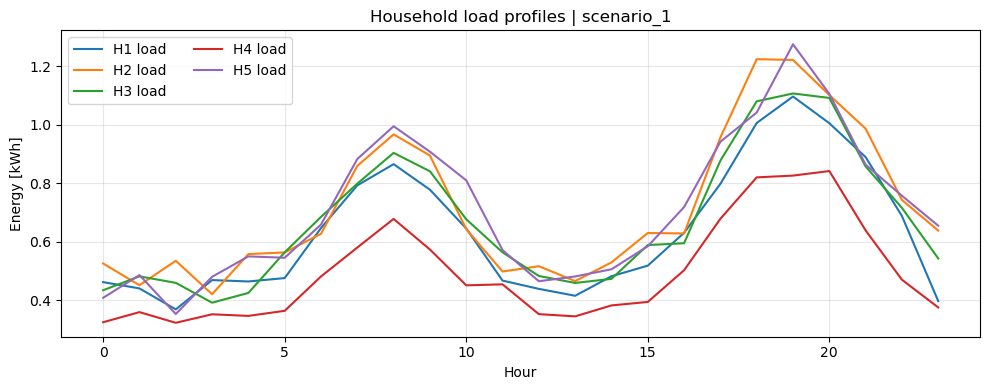

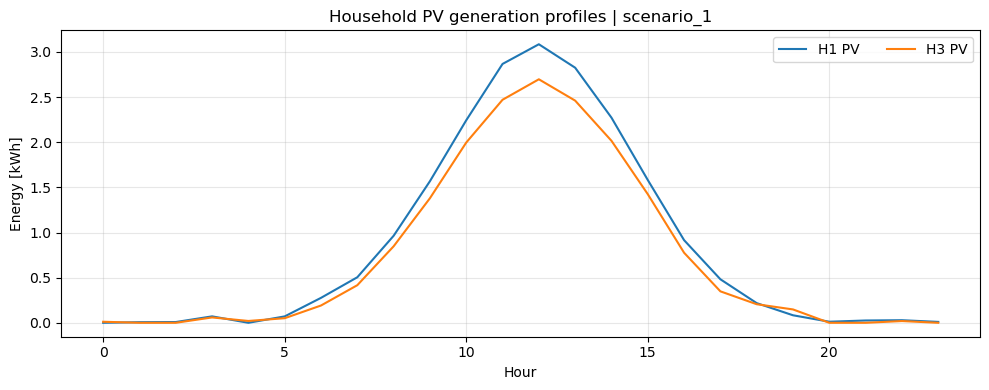

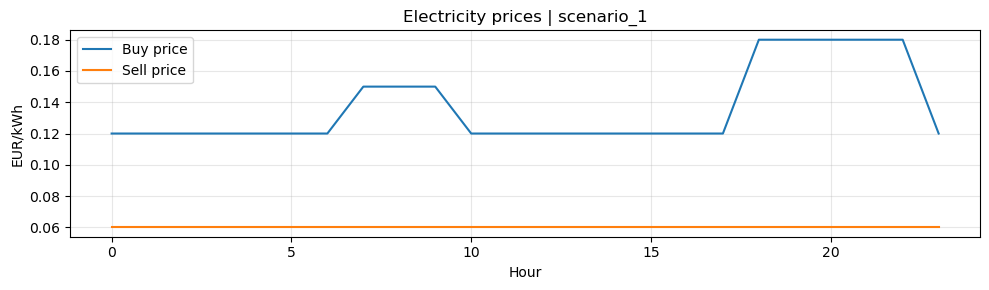

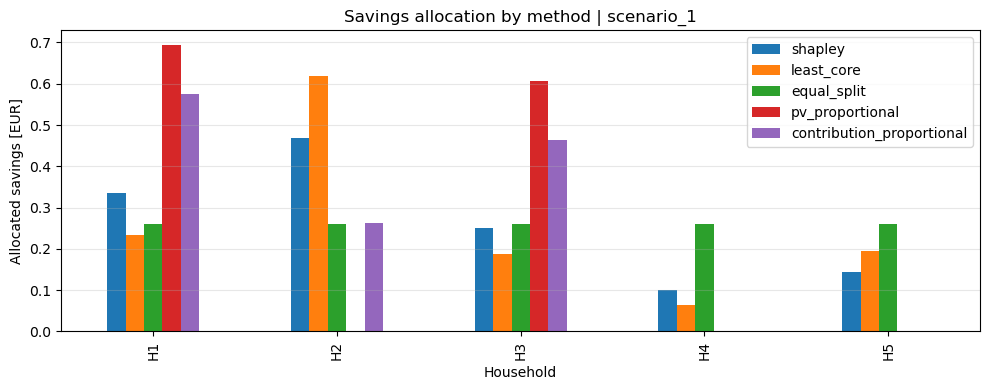

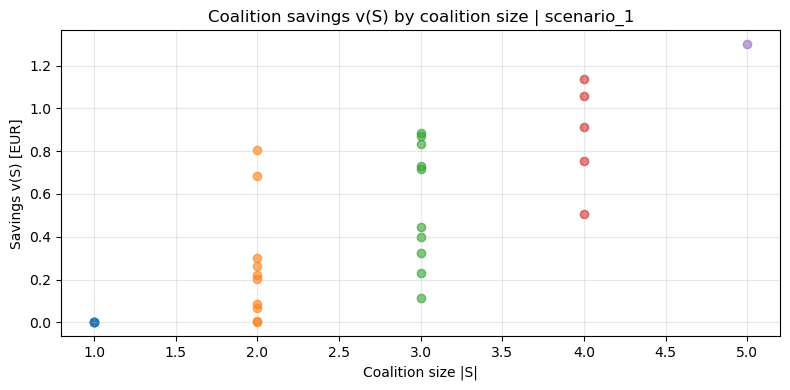

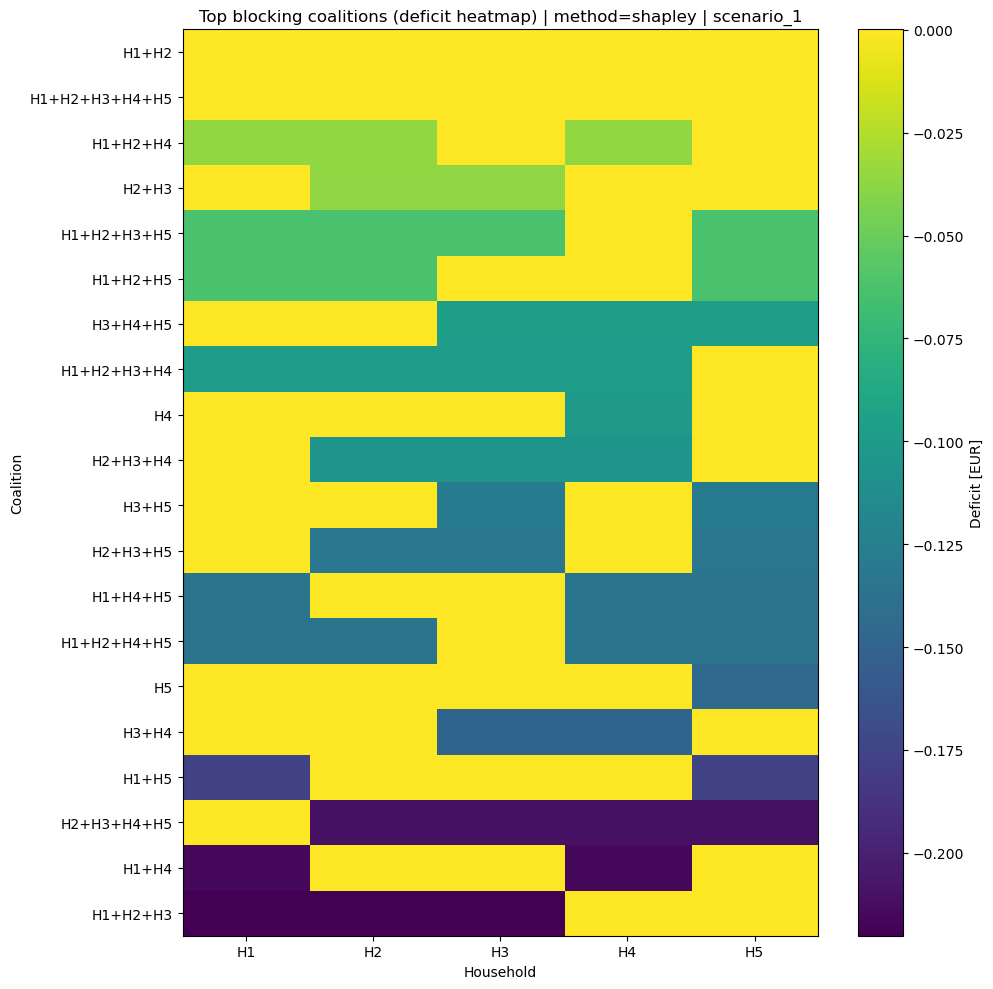

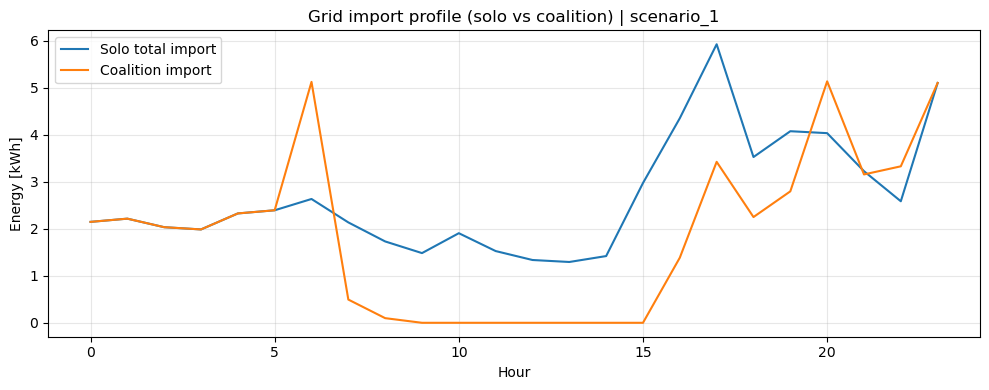

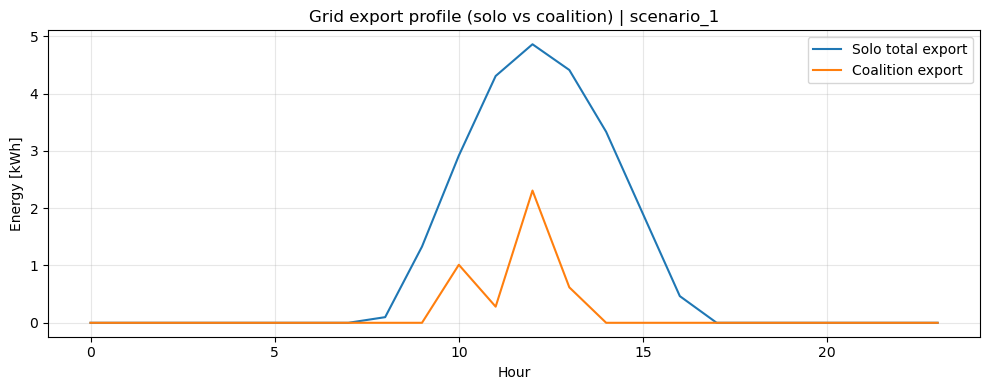

In [89]:
scenario = scenario_from_proposal("scenario_1")
run = run_scenario_end_to_end(scenario)

plot_input_profiles(scenario)
plot_allocation_bars(run)
plot_coalition_value_by_size(run)
plot_blocking_coalitions_heatmap(run, method_name="shapley")
plot_import_export_profiles(run)

In [90]:
def save_current_figure(filename: str) -> None:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(FIG_DIR / filename, dpi=200, bbox_inches="tight")


def render_and_save_main_figures(scenario: ScenarioData, run: ScenarioRunResult) -> None:
    # 1) Input profiles
    plot_input_profiles(scenario)
    # plot_input_profiles pravi 3 odvojene figure, pa ih je bolje prepraviti kasnije;
    # za sada ove neće biti pouzdano sačuvane odavde.

    # 2) Allocation bars
    players = run.players
    methods = ["shapley", "least_core", "equal_split", "pv_proportional", "contribution_proportional"]
    df = pd.DataFrame({m: [run.allocations[m][p] for p in players] for m in methods}, index=players)

    ax = df.plot(kind="bar", figsize=(10, 4))
    ax.set_title(f"Savings Allocation by Method | {run.scenario_name}")
    ax.set_xlabel("Household")
    ax.set_ylabel("Allocated Savings [EUR]")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    save_current_figure(f"allocation_bars_{run.scenario_name}.png")
    plt.show()

    # 3) Coalition values by size
    records = []
    for S, val in run.v.items():
        if len(S) == 0:
            continue
        records.append({"coalition": "+".join(sorted(S)), "size": len(S), "v_S": val})
    dfv = pd.DataFrame(records)

    plt.figure(figsize=(8, 4))
    for size in sorted(dfv["size"].unique()):
        subset = dfv[dfv["size"] == size]
        plt.scatter([size] * len(subset), subset["v_S"].values, alpha=0.6)
    plt.title(f"Coalition Savings v(S) by Coalition Size | {run.scenario_name}")
    plt.xlabel("Coalition Size |S|")
    plt.ylabel("Savings v(S) [EUR]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_current_figure(f"coalition_values_by_size_{run.scenario_name}.png")
    plt.show()

    # 4) Blocking coalition heatmap
    alloc = run.allocations["shapley"]
    records = []
    for S, vS in run.v.items():
        if len(S) == 0:
            continue
        lhs = sum(alloc.get(p, 0.0) for p in S)
        deficit = vS - lhs
        records.append({"coalition": "+".join(sorted(S)), "size": len(S), "deficit": deficit})

    dfd = pd.DataFrame(records).sort_values(by="deficit", ascending=False).head(20)

    mat = np.zeros((len(dfd), len(players)), dtype=float)
    for r, label in enumerate(dfd["coalition"].tolist()):
        members = set(label.split("+"))
        for c, p in enumerate(players):
            mat[r, c] = dfd.iloc[r]["deficit"] if p in members else 0.0

    plt.figure(figsize=(10, 0.4 * len(dfd) + 2))
    if sns is not None:
        sns.heatmap(
            mat,
            yticklabels=dfd["coalition"].tolist(),
            xticklabels=players,
            cmap="Reds",
            cbar_kws={"label": "Deficit [EUR]"},
        )
    else:
        plt.imshow(mat, aspect="auto")
        plt.yticks(range(len(dfd)), dfd["coalition"].tolist())
        plt.xticks(range(len(players)), players)
        plt.colorbar(label="Deficit [EUR]")

    plt.title(f"Top Blocking Coalitions | Shapley | {run.scenario_name}")
    plt.xlabel("Household")
    plt.ylabel("Coalition")
    plt.tight_layout()
    save_current_figure(f"blocking_heatmap_shapley_{run.scenario_name}.png")
    plt.show()

    # 5) Import/export profiles
    hours = run.solo_outcomes[run.players[0]].import_kwh.shape[0]
    x = np.arange(hours)

    solo_import = np.zeros(hours)
    solo_export = np.zeros(hours)
    for p in run.players:
        solo_import += run.solo_outcomes[p].import_kwh
        solo_export += run.solo_outcomes[p].export_kwh

    plt.figure(figsize=(10, 4))
    plt.plot(x, solo_import, label="Solo total import")
    plt.plot(x, run.grand_outcome.import_kwh, label="Coalition import")
    plt.title(f"Grid Import Profile | {run.scenario_name}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    save_current_figure(f"grid_import_{run.scenario_name}.png")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(x, solo_export, label="Solo total export")
    plt.plot(x, run.grand_outcome.export_kwh, label="Coalition export")
    plt.title(f"Grid Export Profile | {run.scenario_name}")
    plt.xlabel("Hour")
    plt.ylabel("Energy [kWh]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    save_current_figure(f"grid_export_{run.scenario_name}.png")
    plt.show()

/home/ognjen/miniconda3/envs/game_theory_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ognjen/miniconda3/envs/game_theory_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


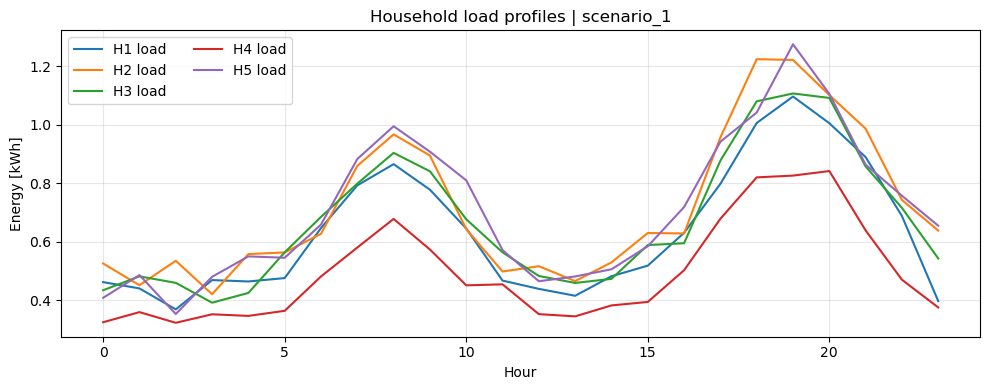

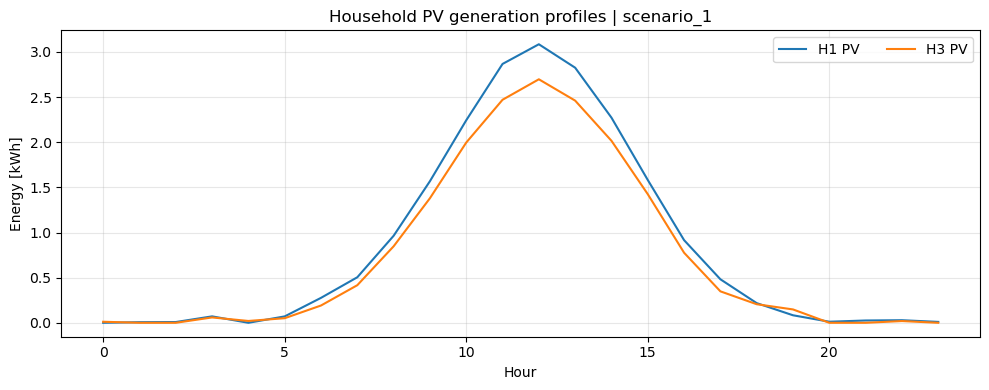

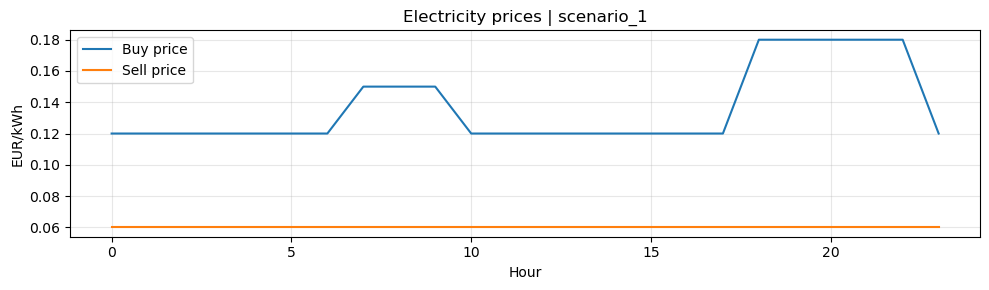

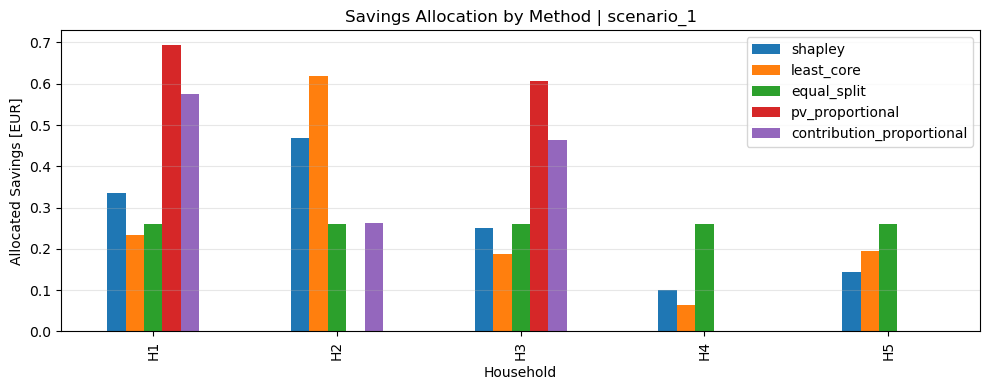

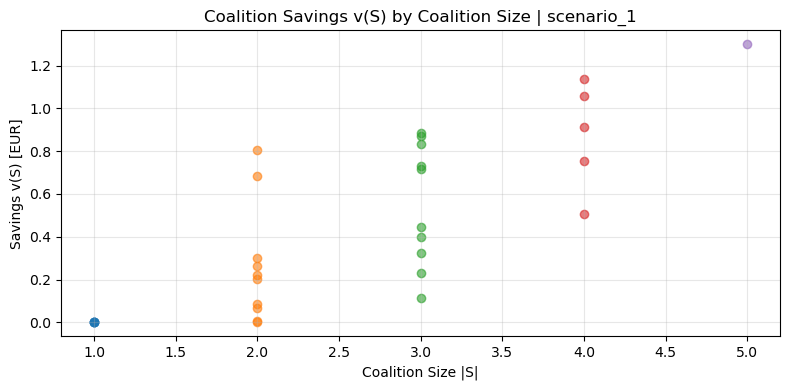

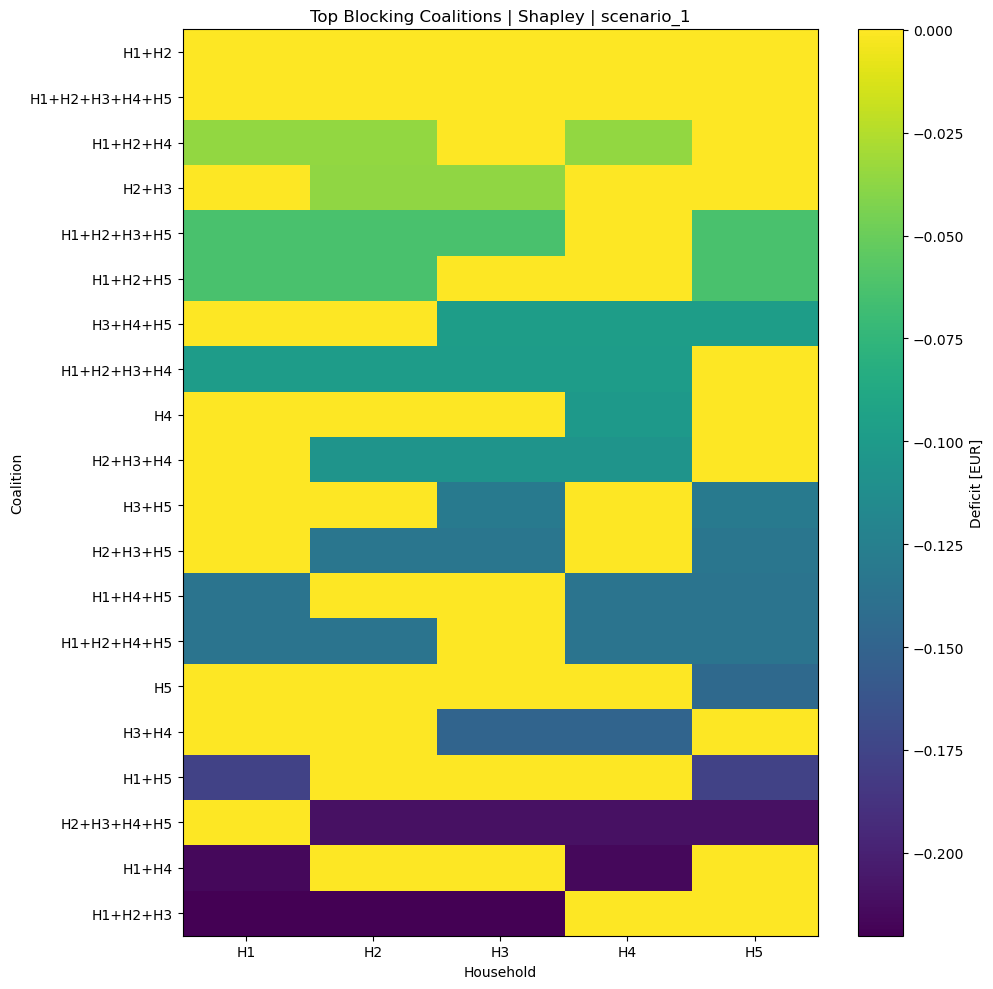

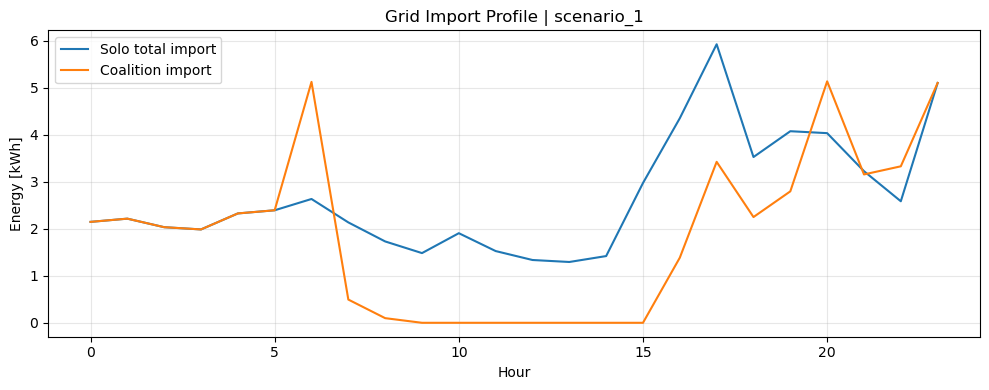

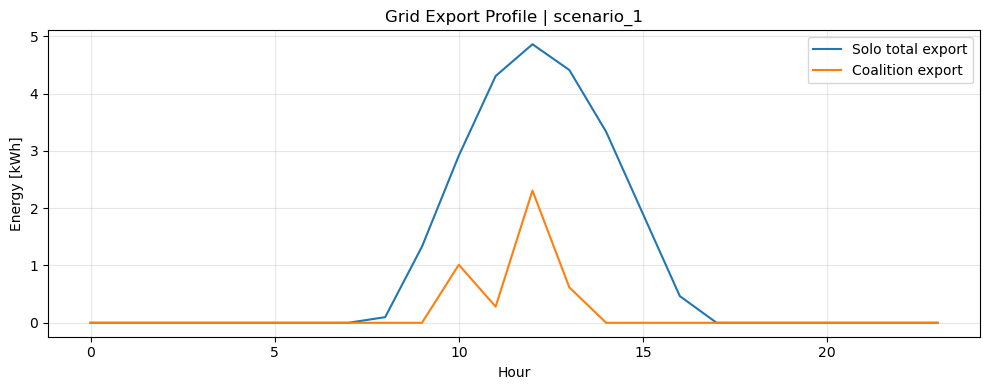

Saved figure files:
 - allocation_bars_scenario_1.png
 - blocking_heatmap_shapley_scenario_1.png
 - coalition_values_by_size_scenario_1.png
 - grid_export_scenario_1.png
 - grid_import_scenario_1.png


In [91]:
scenario = scenario_from_proposal("scenario_1")
run = run_scenario_end_to_end(scenario)

render_and_save_main_figures(scenario, run)

print("Saved figure files:")
for p in sorted(FIG_DIR.glob("*")):
    print(" -", p.name)